In [1]:
!pip install pandas

In [3]:
!pip install matplotlib seaborn scikit-learn

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [6]:
df = pd.read_csv(r"C:\Users\rakesh\Documents\SQL files\argo srs files\for predictions\listing_prediction_data.csv")

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   listing_id      88 non-null     int64  
 1   title           88 non-null     object 
 2   category        88 non-null     object 
 3   starting_value  88 non-null     float64
 4   num_bids        88 non-null     int64  
 5   final_price     87 non-null     float64
dtypes: float64(2), int64(2), object(2)
memory usage: 4.3+ KB


listing_id        0
title             0
category          0
starting_value    0
num_bids          0
final_price       1
dtype: int64

In [8]:
df = df.dropna(subset=['final_price'])

In [10]:
df['category'] = df['category'].astype('category')
df['category_encoded'] = df['category'].cat.codes

In [11]:
X = df[['starting_value', 'num_bids', 'category_encoded']]
y = df['final_price']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [15]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.9569
RMSE: 132.30


In [16]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})
print(comparison.head(10))

   Actual Price  Predicted Price
0       2126.10      2130.689359
1       1664.49      1900.357345
2       2819.85      2897.008283
3       1495.57      1584.599316
4       2695.40      2664.001323
5       3039.22      2952.335289
6       1919.47      2138.810709
7       1846.04      1748.582370
8       1178.57      1342.771488
9       1504.82      1468.343958


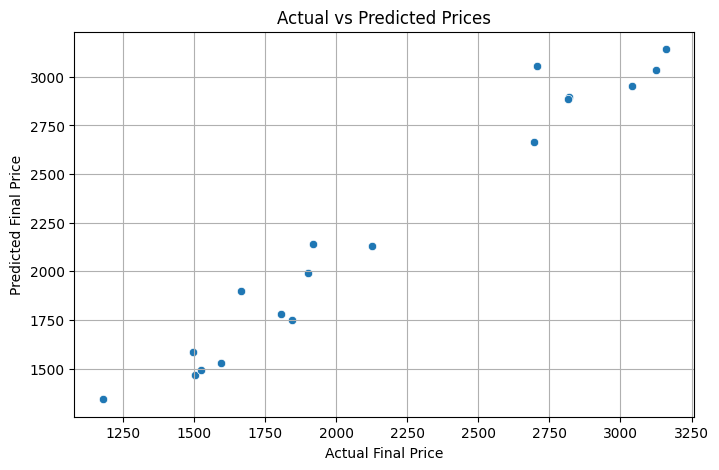

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Final Price')
plt.ylabel('Predicted Final Price')
plt.title('Actual vs Predicted Prices')
plt.grid(True)
plt.show()